# 1. Objective

Notebook ini memperbarui target klasifikasi kondisi keuangan bulanan personal user berbasis cashflow:

- monthly_financial_condition (numeric)
- monthly_financial_condition_label (text)

Mapping kelas final:
- 0 = survival
- 1 = stable
- 2 = growth

Prinsip utama:
- Fokus pada kondisi cashflow bulanan personal user.
- Tidak memakai financial_scenario, cash_flow_status, financial_stress_level untuk membentuk label.
- Tidak membuat feature input baru permanen untuk model.
- Tidak ada random logic dan tidak memakai informasi masa depan.
- Output dataset hanya menambah dua kolom label final.

## 2. Import Libraries

Import library untuk data processing, validasi, dan visualisasi.

In [49]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("FINARY_FIXED_FINAL_DATASET.csv")
OUT_PATH = Path("FINARY_MONTHLY_CONDITION_DATASET.csv")

print("DATA_PATH:", DATA_PATH)
print("OUT_PATH :", OUT_PATH)

DATA_PATH: FINARY_FIXED_FINAL_DATASET.csv
OUT_PATH : FINARY_MONTHLY_CONDITION_DATASET.csv


## 3. Load Dataset

Load dataset input tanpa overwrite dataset lama.

In [50]:
if OUT_PATH.resolve() == DATA_PATH.resolve():
    raise ValueError("OUT_PATH tidak boleh sama dengan DATA_PATH")

df = pd.read_csv(DATA_PATH)
print("Input shape:", df.shape)
display(df.head(3))

Input shape: (3000, 43)


,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,investment_amount,subscription_services,...,category_Healthcare,category_Insurance,category_Investments,category_Rent,category_Transportation,category_Utilities,cash_flow_status_Neutral,cash_flow_status_Positive,financial_stress_level_Low,financial_stress_level_Medium
0,3119.58,3212.07,0.38,3676.11,0,721.0,0.56,125.77,689.22,3,...,False,False,True,False,False,False,False,True,True,False
1,3262.44,3732.81,0.10,2607.17,0,670.0,0.42,454.19,360.34,4,...,False,False,True,False,False,False,False,True,True,False
2,2931.20,3335.58,0.15,3004.14,0,691.0,0.24,971.82,0.00,5,...,True,False,False,False,False,False,False,True,True,False


## 4. Validate Required Columns

Validasi seluruh kolom existing yang dipakai untuk pembentukan label baru.

In [51]:
REQUIRED_LABEL_COLS = [
    "monthly_income",
    "monthly_expense_total",
    "net_cash_flow",
    "expense_ratio",
    "actual_savings",
    "savings_rate",
]

missing_required = [c for c in REQUIRED_LABEL_COLS if c not in df.columns]
if missing_required:
    raise KeyError(f"Dataset missing required columns: {missing_required}")

print("All required columns for final labeling are present.")

All required columns for final labeling are present.


## 5. Audit Existing Labels and Financial Features

Audit label lama untuk analisis saja dan ringkasan fitur finansial yang dipakai untuk labeling baru.

In [52]:
old_label_cols = ["financial_scenario", "cash_flow_status", "financial_stress_level"]

print("Old label columns availability (analysis only):")
for col in old_label_cols:
    print(f"- {col}:", col in df.columns)

print("\nFeature quick stats (used for new labeling):")
display(df[REQUIRED_LABEL_COLS].describe(include="all").T)

missing_rate = df[REQUIRED_LABEL_COLS].isna().mean().sort_values(ascending=False)
print("Top missing ratio (required features):")
display(missing_rate)

Old label columns availability (analysis only):
- financial_scenario: True
- cash_flow_status: False
- financial_stress_level: False

Feature quick stats (used for new labeling):


,count,mean,std,min,25%,50%,75%,max
monthly_income,3000.0,4004.267347,1000.107096,685.280000,3362.250000,4008.07500,4659.040000,7407.94000
monthly_expense_total,3000.0,3011.682230,801.151864,159.210000,2473.205000,3023.81000,3555.502500,5853.20000
net_cash_flow,3000.0,992.585117,1282.014697,-3062.440000,144.965000,1032.81000,1821.510000,6589.66000
expense_ratio,3000.0,0.813760,0.368857,0.034636,0.583034,0.74887,0.956486,5.46092
actual_savings,3000.0,1156.418457,1039.597384,0.000000,144.965000,1032.81000,1821.510000,6589.66000
savings_rate,3000.0,0.225897,0.101417,0.050000,0.140000,0.23000,0.310000,0.40000


Top missing ratio (required features):


monthly_income           0.0
monthly_expense_total    0.0
net_cash_flow            0.0
expense_ratio            0.0
actual_savings           0.0
savings_rate             0.0
dtype: float64

## 6. Define Financial Health Labeling Rules

Definisikan rule labeling berbasis net cashflow margin bulanan:

- survival: net_margin_ratio < 0 atau monthly_income <= 0
- stable: 0 <= net_margin_ratio < 0.15
- growth: net_margin_ratio >= 0.15

In [53]:
LABEL_MAP = {0: "survival", 1: "stable", 2: "growth"}

NET_MARGIN_STABLE_UPPER = 0.15

print("Rules defined.")
print("- income <= 0 => survival")
print("- net_margin_ratio < 0 => survival")
print("- 0 <= net_margin_ratio < 0.15 => stable")
print("- net_margin_ratio >= 0.15 => growth")

Rules defined.
- income <= 0 => survival
- net_margin_ratio < 0 => survival
- 0 <= net_margin_ratio < 0.15 => stable
- net_margin_ratio >= 0.15 => growth


## 7. Generate monthly_financial_condition

Bentuk label baru secara vectorized. Variabel temporary net_margin_ratio hanya dipakai di memory dan tidak disimpan ke dataset final.

In [54]:
def build_labels(input_df: pd.DataFrame) -> pd.DataFrame:
    out = input_df.copy()

    monthly_income = out["monthly_income"].astype(float)
    net_cash_flow = out["net_cash_flow"].astype(float)

    # Temporary in-memory metric only (not saved as a permanent column).
    net_margin_ratio = np.where(monthly_income > 0, net_cash_flow / monthly_income, np.nan)

    survival_mask = (monthly_income <= 0) | (net_margin_ratio < 0)
    stable_mask = (~survival_mask) & (net_margin_ratio < NET_MARGIN_STABLE_UPPER)
    growth_mask = (~survival_mask) & (~stable_mask)

    labels = np.ones(len(out), dtype=int)
    labels[survival_mask.values] = 0
    labels[stable_mask] = 1
    labels[growth_mask] = 2

    out["monthly_financial_condition"] = labels
    out["monthly_financial_condition_label"] = pd.Series(labels).map(LABEL_MAP).astype(str)
    return out


df_out = build_labels(df)
display(df_out[["monthly_financial_condition", "monthly_financial_condition_label"]].head(10))

,monthly_financial_condition,monthly_financial_condition_label
0,0,survival
1,0,survival
2,0,survival
3,2,growth
4,2,growth
5,1,stable
6,2,growth
7,2,growth
8,2,growth
9,1,stable


## 8. Validate Class Distribution

Tampilkan distribusi dan persentase kelas untuk label baru. Jika ada kelas dengan proporsi < 10%, tampilkan warning.

In [55]:
def dist_report(series: pd.Series) -> pd.DataFrame:
    vc = series.value_counts(dropna=False)
    pct = (vc / vc.sum() * 100).round(2)
    return pd.DataFrame({"count": vc, "pct": pct})

print("Distribution: monthly_financial_condition")
display(dist_report(df_out["monthly_financial_condition"]))

print("Distribution: monthly_financial_condition_label")
label_dist = dist_report(df_out["monthly_financial_condition_label"])
display(label_dist)

small_classes = label_dist[label_dist["pct"] < 10.0]
if not small_classes.empty:
    print("WARNING: terdapat kelas dengan proporsi < 10%")
    for idx, row in small_classes.iterrows():
        print(f"- {idx}: {row['pct']:.2f}%")
else:
    print("Distribusi kelas tidak ekstrem (semua kelas >= 10%).")

Distribution: monthly_financial_condition


,count,pct
monthly_financial_condition,,
2,1911,63.7
0,651,21.7
1,438,14.6


Distribution: monthly_financial_condition_label


,count,pct
monthly_financial_condition_label,,
growth,1911,63.7
survival,651,21.7
stable,438,14.6


Distribusi kelas tidak ekstrem (semua kelas >= 10%).


## 9. Compare New Label vs Old Labels

Bandingkan label baru dengan label lama hanya untuk analisis, bukan untuk membentuk label.

In [56]:
print("Distribution: monthly_financial_condition")
display(dist_report(df_out["monthly_financial_condition"]))

print("Distribution: monthly_financial_condition_label")
display(dist_report(df_out["monthly_financial_condition_label"]))

if "financial_scenario" in df_out.columns:
    print("\nCrosstab: financial_scenario vs monthly_financial_condition_label (column-normalized %)")
    ct = pd.crosstab(
        df_out["financial_scenario"],
        df_out["monthly_financial_condition_label"],
        normalize="columns",
    )
    display((ct * 100).round(2))
else:
    print("Column financial_scenario not found, skipping crosstab.")

for col in ["cash_flow_status", "financial_stress_level"]:
    if col in df_out.columns:
        print(f"\nOptional crosstab: {col} vs monthly_financial_condition_label")
        ct_opt = pd.crosstab(df_out[col], df_out["monthly_financial_condition_label"], normalize="columns")
        display((ct_opt * 100).round(2))
    else:
        print(f"Column {col} not found, safely skipped.")

Distribution: monthly_financial_condition


,count,pct
monthly_financial_condition,,
2,1911,63.7
0,651,21.7
1,438,14.6


Distribution: monthly_financial_condition_label


,count,pct
monthly_financial_condition_label,,
growth,1911,63.7
survival,651,21.7
stable,438,14.6



Crosstab: financial_scenario vs monthly_financial_condition_label (column-normalized %)


monthly_financial_condition_label,growth,stable,survival
financial_scenario,,,
0,21.09,23.29,21.97
1,59.45,54.79,55.76
2,19.47,21.92,22.27


Column cash_flow_status not found, safely skipped.
Column financial_stress_level not found, safely skipped.


## 10. Analyze Feature Relationship with New Label

Buat group summary untuk mengecek pola survival, stable, dan growth berdasarkan fitur finansial utama.

In [57]:
group_cols = [
    "monthly_income",
    "monthly_expense_total",
    "net_cash_flow",
    "expense_ratio",
    "actual_savings",
    "savings_rate",
]

missing_group = [c for c in group_cols if c not in df_out.columns]
if missing_group:
    raise KeyError(f"Missing required feature columns for group analysis: {missing_group}")

summary = df_out.groupby("monthly_financial_condition_label")[group_cols].agg(["mean", "median"])
display(summary)

print("\nInterpretation guide:")
print("- survival: net_cash_flow negatif atau paling rendah")
print("- stable  : net_cash_flow positif tetapi margin tipis")
print("- growth  : net_cash_flow positif dan margin lebih kuat")

monthly_income           \
                                            mean   median   
monthly_financial_condition_label                           
growth                               4432.027949  4403.12   
stable                               3689.612557  3685.05   
survival                             2960.286221  2979.88   

                                  monthly_expense_total           \
                                                   mean   median   
monthly_financial_condition_label                                  
growth                                      2685.009074  2692.09   
stable                                      3391.205479  3407.21   
survival                                    3715.278571  3700.17   

                                  net_cash_flow           expense_ratio  \
                                           mean    median          mean   
monthly_financial_condition_label                                         
growth                              1747.018875  1594.990      0.614791   
stable                               298.407078   285.345      0.920181   
survival                            -754.992350  -620.410      1.326229   

                                            actual_savings            \
                                     median           mean    median   
monthly_financial_condition_label                                      
growth                             0.628847    1747.018875  1594.990   
stable                             0.920787     298.407078   285.345   
survival                           1.201455       0.000000     0.000   

                                  savings_rate         
                                          mean median  
monthly_financial_condition_label                      
growth                                0.225730   0.22  
stable                                0.225799   0.23  
survival                              0.226452   0.23


Interpretation guide:
- survival: net_cash_flow negatif atau paling rendah
- stable  : net_cash_flow positif tetapi margin tipis
- growth  : net_cash_flow positif dan margin lebih kuat


## 11. Visualize Class Separability

Visualisasi wajib: boxplot fitur inti, countplot label baru, dan correlation heatmap untuk fitur numerik utama.

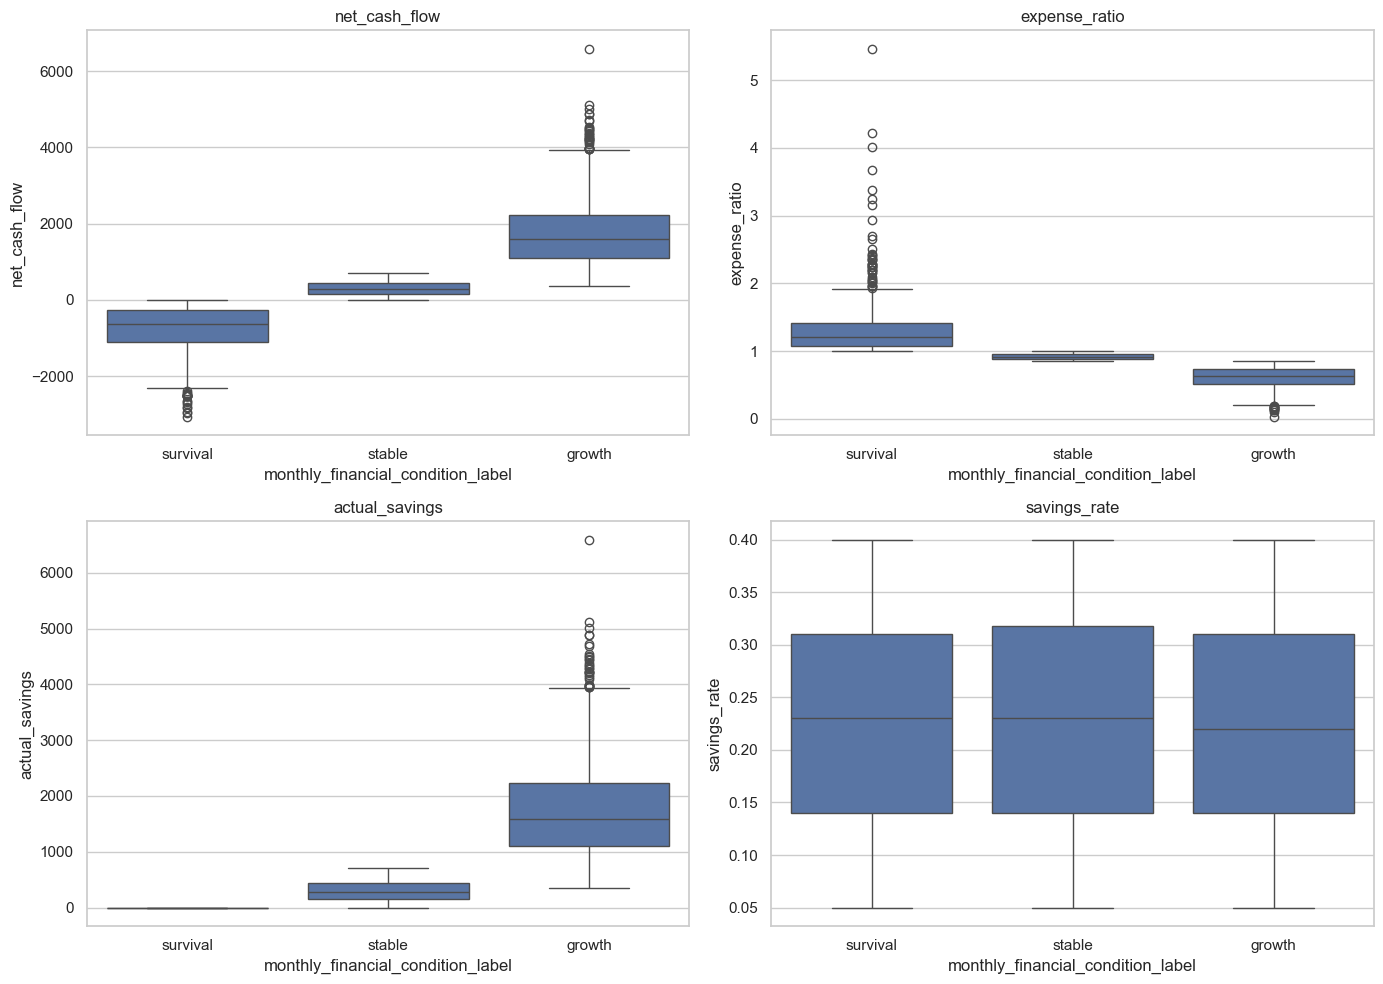

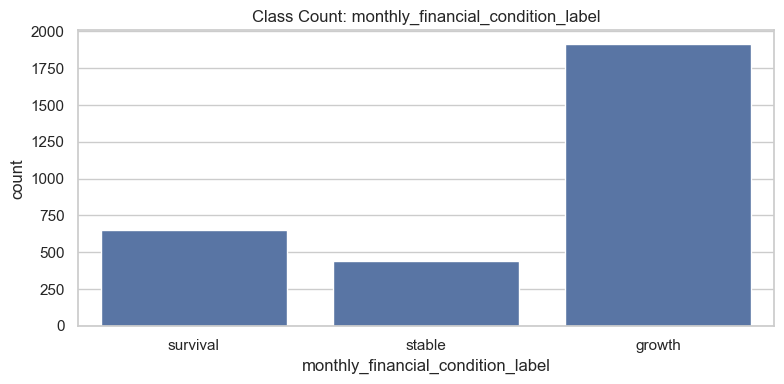

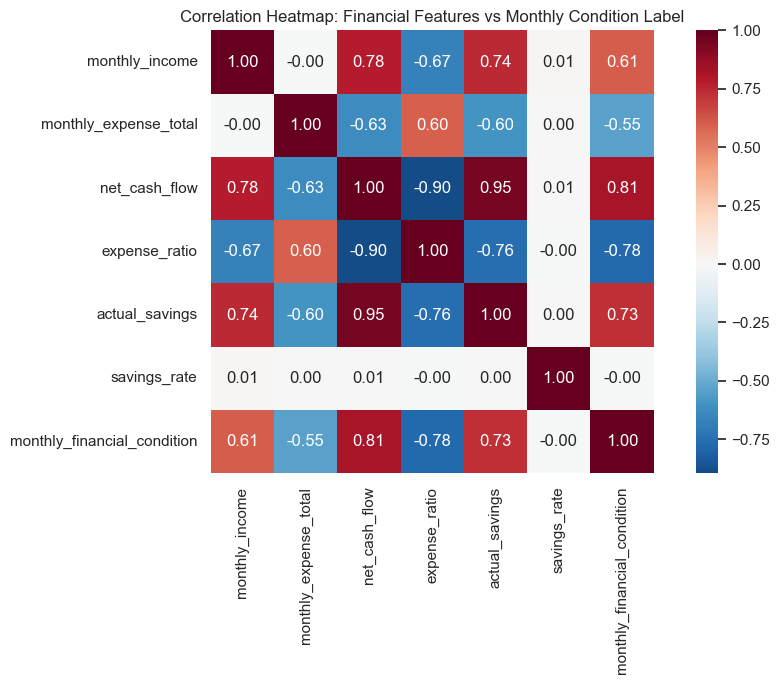

In [61]:
order = ["survival", "stable", "growth"]

box_cols = [
    "net_cash_flow",
    "expense_ratio",
    "actual_savings",
    "savings_rate",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(box_cols):
    sns.boxplot(data=df_out, x="monthly_financial_condition_label", y=col, order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("monthly_financial_condition_label")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(data=df_out, x="monthly_financial_condition_label", order=order)
plt.title("Class Count: monthly_financial_condition_label")
plt.xlabel("monthly_financial_condition_label")
plt.tight_layout()
plt.show()

# Correlation heatmap for key numeric features and label code.
corr_cols = [
    "monthly_income",
    "monthly_expense_total",
    "net_cash_flow",
    "expense_ratio",
    "actual_savings",
    "savings_rate",
    "monthly_financial_condition",
]
corr_df = df_out[corr_cols].copy()
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation Heatmap: Financial Features vs Monthly Condition Label")
plt.tight_layout()
plt.show()

## 12. Save New Dataset

Simpan dataset final ke FINARY_MONTHLY_CONDITION_DATASET.csv tanpa menyimpan kolom sementara.

In [59]:
required_new_cols = ["monthly_financial_condition", "monthly_financial_condition_label"]
for col in required_new_cols:
    if col not in df_out.columns:
        raise KeyError(f"Missing new label column: {col}")

added_cols = [c for c in df_out.columns if c not in df.columns]
if sorted(added_cols) != sorted(required_new_cols):
    raise ValueError(f"Only two new label columns are allowed. Found added columns: {added_cols}")

forbidden_temp_cols = ["net_margin_ratio", "risk_score", "condition_score", "temporary_flag"]
found_forbidden = [c for c in forbidden_temp_cols if c in df_out.columns]
if found_forbidden:
    raise ValueError(f"Temporary/helper columns must not be saved: {found_forbidden}")

df_out.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)
print("Output shape:", df_out.shape)

Saved: FINARY_MONTHLY_CONDITION_DATASET.csv
Output shape: (3000, 45)


## 13. Reload and Verify Saved Dataset

Reload hasil simpan untuk verifikasi shape, head, distribusi kelas baru, dan memastikan hanya dua kolom baru yang bertambah.

In [60]:
df_check = pd.read_csv(OUT_PATH)
print("Reloaded shape:", df_check.shape)
display(df_check.head(3))

for col in ["monthly_financial_condition", "monthly_financial_condition_label"]:
    if col not in df_check.columns:
        raise KeyError(f"Required output column missing after reload: {col}")

added_cols_reloaded = [c for c in df_check.columns if c not in df.columns]
print("Added columns after reload:", added_cols_reloaded)
if sorted(added_cols_reloaded) != sorted(["monthly_financial_condition", "monthly_financial_condition_label"]):
    raise ValueError("Output must contain only two added label columns.")

forbidden_temp_cols = ["net_margin_ratio", "risk_score", "condition_score", "temporary_flag"]
found_forbidden = [c for c in forbidden_temp_cols if c in df_check.columns]
if found_forbidden:
    raise ValueError(f"Temporary/helper columns found in saved dataset: {found_forbidden}")

print("Distribution (reloaded): monthly_financial_condition")
display(dist_report(df_check["monthly_financial_condition"]))

print("Distribution (reloaded): monthly_financial_condition_label")
display(dist_report(df_check["monthly_financial_condition_label"]))

Reloaded shape: (3000, 45)


,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,investment_amount,subscription_services,...,category_Investments,category_Rent,category_Transportation,category_Utilities,cash_flow_status_Neutral,cash_flow_status_Positive,financial_stress_level_Low,financial_stress_level_Medium,monthly_financial_condition,monthly_financial_condition_label
0,3119.58,3212.07,0.38,3676.11,0,721.0,0.56,125.77,689.22,3,...,True,False,False,False,False,True,True,False,0,survival
1,3262.44,3732.81,0.10,2607.17,0,670.0,0.42,454.19,360.34,4,...,True,False,False,False,False,True,True,False,0,survival
2,2931.20,3335.58,0.15,3004.14,0,691.0,0.24,971.82,0.00,5,...,False,False,False,False,False,True,True,False,0,survival


Added columns after reload: ['monthly_financial_condition', 'monthly_financial_condition_label']
Distribution (reloaded): monthly_financial_condition


,count,pct
monthly_financial_condition,,
2,1911,63.7
0,651,21.7
1,438,14.6


Distribution (reloaded): monthly_financial_condition_label


,count,pct
monthly_financial_condition_label,,
growth,1911,63.7
survival,651,21.7
stable,438,14.6


## 14. Final Summary

The target was reframed into monthly cashflow-based financial condition because the original synthetic labels showed weak class separability. The new label uses only existing financial columns and is directly aligned with the product goal: identifying whether a user is in survival, stable, or growth financial condition for the month.

Catatan untuk notebook training berikutnya:
- Gunakan FINARY_MONTHLY_CONDITION_DATASET.csv
- Target utama: monthly_financial_condition
- Label mapping: 0 = survival, 1 = stable, 2 = growth
- Jangan ubah notebook training model dulu kecuali sudah diarahkan.